This notebook is an entry to the Housing Prices Kaggle competition; it scores a 0.12480. 

We start with EDA, checking the distribution of the sales prices, impute missing values, check covariances of a subset of features, and engineer new features that have strong signals. Throughout we adjust for skewness by applying a log transformation. We encode categorical features with either one-hot encoding or ordinal mapping when appropriate. 

Finally we train 3 seperate models and take the average of their predictions: XGBoost, LightGBM, and Ridge Regressor. In a previous version we checked for the optimal weighted average of these three models but we found that this was heavily skewed towards the training data. 

After making predictions, we check the importance of each feature to inform future updates on this notebook. 





In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


Start by loading training  and test data. We will remove the id from the get-go just to make future analysis easier. MSSubClass is secretly a categorical feature (numbers are just codes) so we will treat the values as strings. 

In [2]:
# Load data
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

train = train.drop('Id', axis=1)
test_ids = test['Id']  # save for submission
test = test.drop('Id', axis=1)

train['MSSubClass'] = train['MSSubClass'].astype(str)
test['MSSubClass'] = test['MSSubClass'].astype(str)

print(train.shape)
print(train.head())
print(train.dtypes.value_counts())

(1460, 80)
  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape LandContour  \
0         60       RL         65.0     8450   Pave   NaN      Reg         Lvl   
1         20       RL         80.0     9600   Pave   NaN      Reg         Lvl   
2         60       RL         68.0    11250   Pave   NaN      IR1         Lvl   
3         70       RL         60.0     9550   Pave   NaN      IR1         Lvl   
4         60       RL         84.0    14260   Pave   NaN      IR1         Lvl   

  Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0    AllPub    Inside  ...        0    NaN   NaN         NaN       0      2   
1    AllPub       FR2  ...        0    NaN   NaN         NaN       0      5   
2    AllPub    Inside  ...        0    NaN   NaN         NaN       0      9   
3    AllPub    Corner  ...        0    NaN   NaN         NaN       0      2   
4    AllPub       FR2  ...        0    NaN   NaN         NaN       0     12   

   YrSold  SaleType  SaleCo

Very large data set. We will need to extract the most useful features so as to break down the problem in to something more manageable. 

Let's look at the distribution of the sales prices in our data

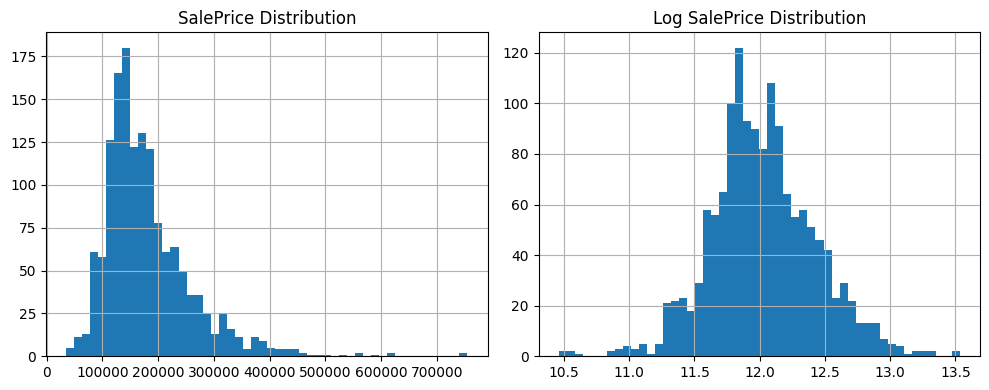

In [3]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train['SalePrice'].hist(bins=50)
plt.title('SalePrice Distribution')

plt.subplot(1, 2, 2)
np.log1p(train['SalePrice']).hist(bins=50)
plt.title('Log SalePrice Distribution')

plt.tight_layout()
plt.show()

We apply a log transformation to normalize the data. Will need to keep this in mind when we make our predictions. 

Now let's account for how messy the data. Let's check for missing values. 

In [4]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal features with missing values: {len(missing)}")

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Total features with missing values: 19


Quite a few. Let's seperate in to numerical and categorical values so that we can fill values consistently. There are two groups for the misssing values: non-existent features vs genuinely missing values. 

The first group is just amenities that the house doesn't have, e.g. pool, alley access, fireplace, etc. Categorical features will be filled with 'None' and numerical features will be filled with zeros. 

The second group are genuinely missing values that probably didn't get logged for some reason or another. LotFrontage, linear feet of street connected to property, will be filled by the median in the neighborhood. MasVnrArea, masonry veneer area in square feet, will be filled by zeros, since this is just a binary feature.  Electrical, the electrical system, will likely be the same for most houses so we just fill with the mode. 

For the rest of the categorical features we will fill with the mode and the numerical features we will fill the median. 



In [5]:
# Group 1 — feature doesn't exist
# Categorical → fill with 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 
             'BsmtFinType1', 'MasVnrType']

for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# Numerical → fill with 0
zero_cols = ['GarageYrBlt']
for col in zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Group 2 — genuinely missing
# LotFrontage — median by neighborhood
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# MasVnrArea — fill with 0
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

# Electrical — fill with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# Categorical — fill with mode
cat_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 
            'KitchenQual', 'Functional', 'SaleType']
for col in cat_cols:
    test[col] = test[col].fillna(test[col].mode()[0])

# Numerical — fill with median
num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in num_cols:
    test[col] = test[col].fillna(test[col].median())

# Verify
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


Now let's reduce the feature space to the top ten features to simplify the problem. We take the absolute value of the correlation to not bias towards positive correlations. 

In [6]:
# Correlation with SalePrice
numeric_features = train.select_dtypes(include=[np.number])
correlations = numeric_features.corr()['SalePrice']
top_features = correlations.abs().sort_values(ascending=False)[1:11].index
print(correlations.sort_values(ascending=False).head(15))
print(correlations.sort_values(ascending=False).tail(5))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.349876
Name: SalePrice, dtype: float64
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


Now that we have the top 10 features, let's check the correlation between the features themselves

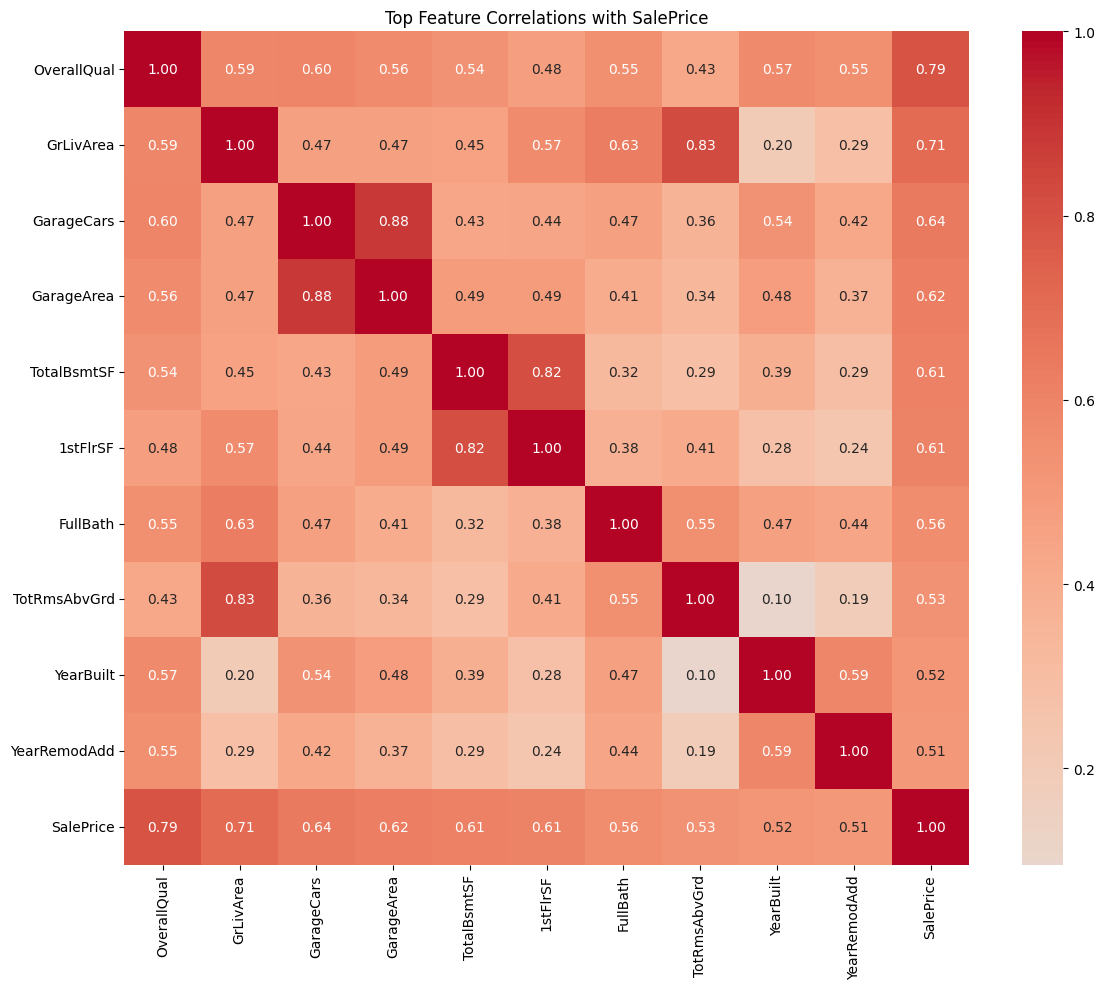

In [7]:
top_features_with_target = list(top_features) + ['SalePrice']

plt.figure(figsize=(12, 10))
sns.heatmap(
    train[top_features_with_target].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Top Feature Correlations with SalePrice')
plt.tight_layout()
plt.show()

Lots of cross-correlations! Surely a number of these features tell a similar story such as GarageArea and GarageCars;  GrLivArea and TotRmsAbvGrd; and 1stFlrSF and TotalBsmtSF. 

Let's get a better idea of the correlations with sales price to better undertstand the relationships. 

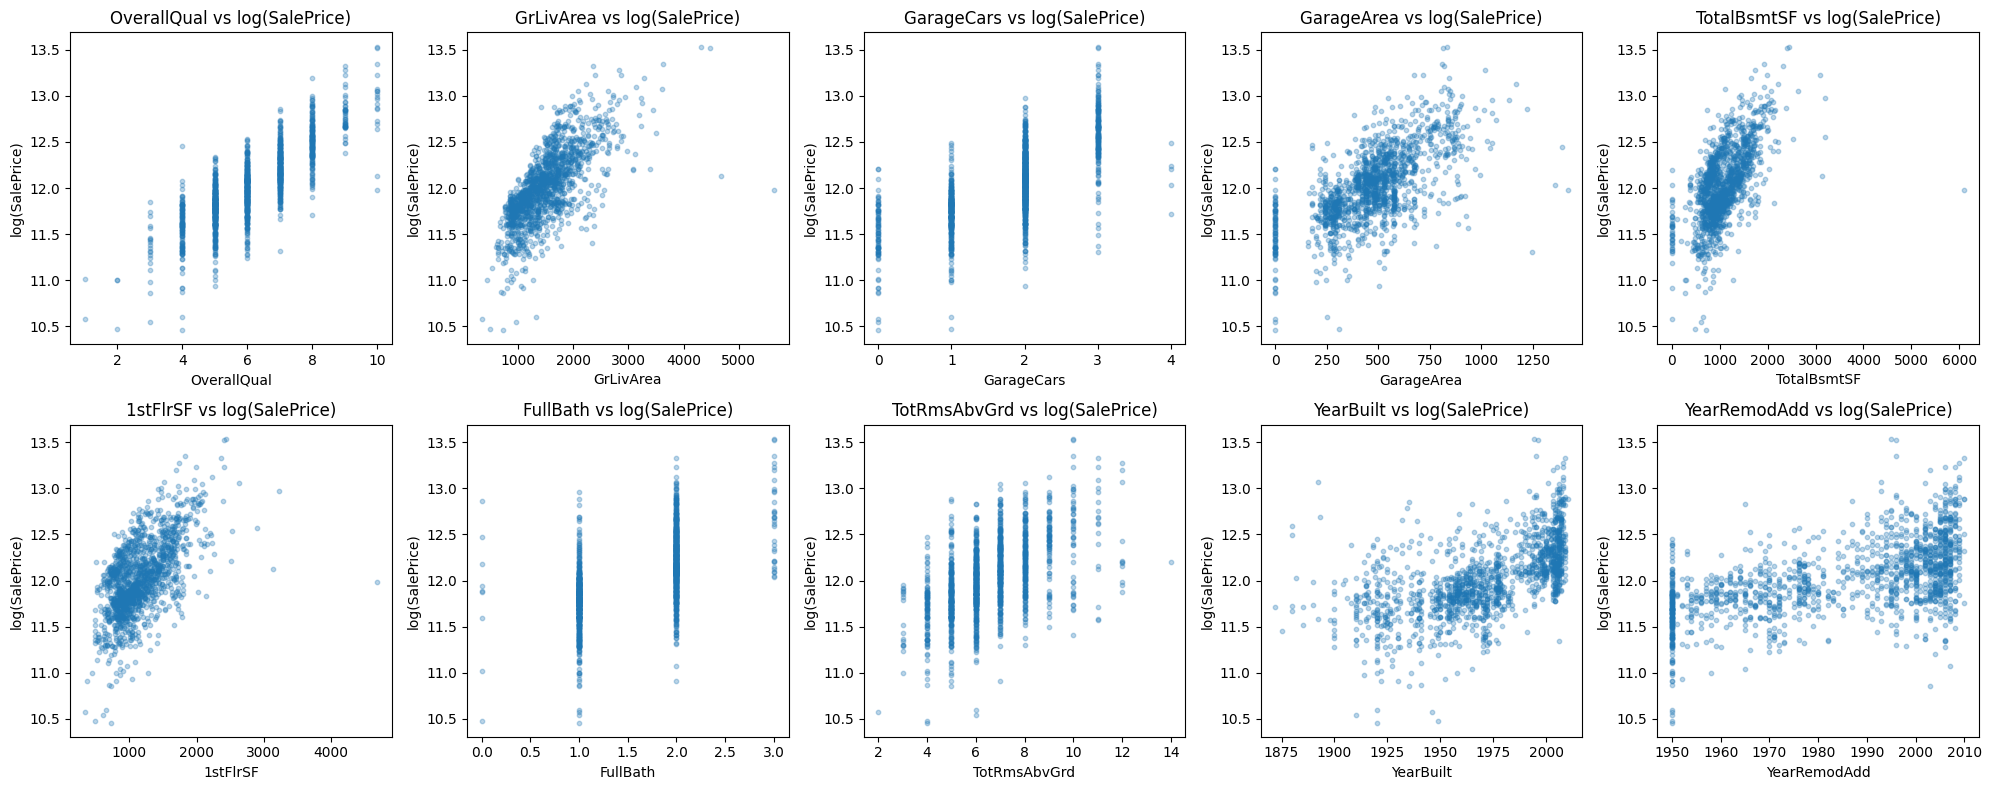

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

top_10 = list(top_features[:10])
log_price = np.log1p(train['SalePrice'])

for i, feature in enumerate(top_10):
    ax = axes[i // 5][i % 5]
    ax.scatter(train[feature], log_price, alpha=0.3, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('log(SalePrice)')
    ax.set_title(f'{feature} vs log(SalePrice)')

plt.tight_layout()
plt.show()

Some interesting features. OverallQual has a strong linear relationship with the log(SalePrice). GrLivArea, TotalBsmntSF, 1stFlrSSF all tell the same story with the same outliers. YearBuilt and YearRemodAdd also tell fairly similar stories except for a buildup around 1950 for the latter. 

Let's first get rid of the outliers. 

In [9]:
# Remove known outliers
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
train = train[~(train['TotalBsmtSF'] > 5000)]

print(f"Training size after outlier removal: {train.shape}")

Training size after outlier removal: (1458, 80)


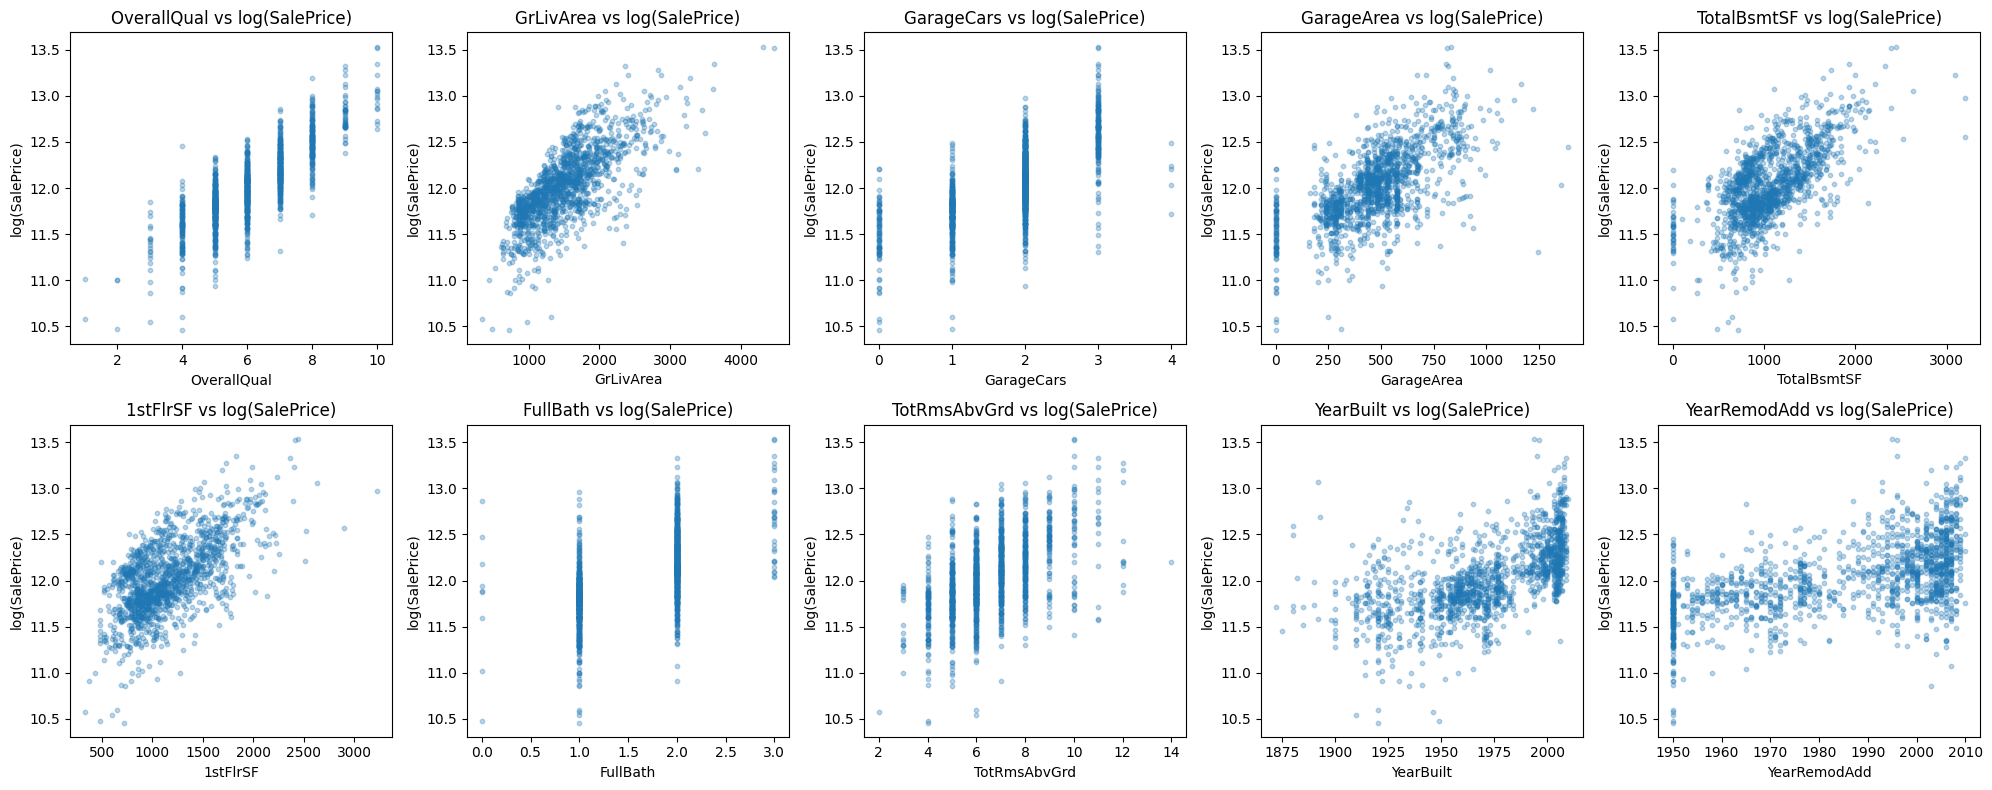

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

top_10 = list(top_features[:10])
log_price = np.log1p(train['SalePrice'])

for i, feature in enumerate(top_10):
    ax = axes[i // 5][i % 5]
    ax.scatter(train[feature], log_price, alpha=0.3, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('log(SalePrice)')
    ax.set_title(f'{feature} vs log(SalePrice)')

plt.tight_layout()
plt.show()

Clearly we can extract more from this information. Let's calculate the total square footage, total baths, house age upon sale, and remodeling age upon sale. 

In [11]:
# Total Square Feet

train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

# Total Baths

train['TotalBath'] = train['FullBath'] + train['HalfBath']*0.5 + train['BsmtFullBath'] + train['BsmtHalfBath']*0.5
test['TotalBath'] = test['FullBath'] + test['HalfBath']*0.5 + test['BsmtFullBath'] + test['BsmtHalfBath']*0.5

#House Age
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

#House Age
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']


In [12]:
new_features = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath']
new_correlations = train[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print(new_correlations)

SalePrice    1.000000
TotalSF      0.832877
TotalBath    0.635896
RemodAge    -0.509706
HouseAge    -0.524067
Name: SalePrice, dtype: float64


These engineered features clearly have very strong correlations with the sale price. Now the question is whether to drop redundant features that went in to the engineered features. Let's take a look at them and their correlation with the sales price

In [13]:
original_features = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 
                     'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
                     'YearBuilt', 'YearRemodAdd']

orig_correlations = train[original_features + ['SalePrice']].corr()['SalePrice'].abs().sort_values(ascending=False)
print(orig_correlations)

SalePrice       1.000000
TotalBsmtSF     0.651153
1stFlrSF        0.631530
FullBath        0.562165
YearBuilt       0.523608
YearRemodAdd    0.507717
2ndFlrSF        0.320532
HalfBath        0.284590
BsmtFullBath    0.228459
BsmtHalfBath    0.016881
Name: SalePrice, dtype: float64


They still have fairly strong correlation until you get to 2ndFlrSF. We will choose a correlation threshold of 0.3 in order to get rid of lower correlation features while keeping 2ndFlrSF, since this tells us something important about the house being sold. 

In [14]:
cols_to_drop = ['HalfBath', 'BsmtFullBath', 'BsmtHalfBath']

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

print(f"Training shape: {train.shape}")
print(f"Test shape: {test.shape}")

Training shape: (1458, 81)
Test shape: (1459, 80)


Now let's work on the skewness of the data. As we saw from the SalePrice, the distribution is skewed left so we implemented a log transformation to get a more normal distribution. Similarly, we should watch out for such skewness in our features. 

In [15]:
from scipy import stats

numeric_features = train.select_dtypes(include=[np.number]).drop('SalePrice', axis=1)

skewness = numeric_features.apply(lambda x: stats.skew(x)).sort_values(ascending=False)

print(skewness[abs(skewness) > 0.75])

MiscVal          24.434913
PoolArea         15.932532
LotArea          12.560986
3SsnPorch        10.286510
LowQualFinSF      8.995688
KitchenAbvGr      4.480268
BsmtFinSF2        4.247550
ScreenPorch       4.114690
EnclosedPorch     3.083987
MasVnrArea        2.693554
OpenPorchSF       2.337421
LotFrontage       1.546174
WoodDeckSF        1.544214
GrLivArea         1.009951
BsmtUnfSF         0.919955
1stFlrSF          0.886723
2ndFlrSF          0.812121
TotalSF           0.803494
BsmtFinSF1        0.764002
GarageYrBlt      -3.862401
dtype: float64


Quite a few heavily skewed features. Let's fix this with a log tranformation. We'll log1p to better account for x = 0. 

In [16]:
skewed_features = skewness[abs(skewness) > 0.75].index

for col in skewed_features:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

We now need to encode the categorical features. Let's explore the space. 

In [17]:
cat_features = train.select_dtypes(include=['object']).columns
print(f"Number of categorical features: {len(cat_features)}")
print(cat_features.tolist())

Number of categorical features: 44
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


Some of these features are purely existence features: is there a pool, fireplace, etc. Other features are quality where there is a ranking based on the value. Let's take care of the latter first with ordinal mapping and the rest with one-hot encoding. 

In [18]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    train[col] = train[col].map(quality_map)
    test[col] = test[col].map(quality_map)

print("Quality columns encoded:")
print(train[quality_cols].head())

Quality columns encoded:
   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  PoolQC  
0            0           3           3       0  
1            3           3           3       0  
2            3           3           3       0  
3            4           3           3       0  
4            3           3           3       0  


In [19]:
# Check remaining categorical features
cat_remaining = train.select_dtypes(include=['object']).columns
print(cat_remaining.tolist())

['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [20]:
# Combine train and test before encoding to ensure same columns
train_size = len(train)

# Separate target
y = np.log1p(train['SalePrice'])
train = train.drop('SalePrice', axis=1)

# Combine
combined = pd.concat([train, test], axis=0)

lot_shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
land_slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
functional_map = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
paved_drive_map = {'Y': 3, 'P': 2, 'N': 1}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}

ordinal_mappings = {
    'LotShape': lot_shape_map,
    'LandSlope': land_slope_map,
    'BsmtExposure': bsmt_exposure_map,
    'BsmtFinType1': bsmt_fin_map,
    'BsmtFinType2': bsmt_fin_map,
    'Functional': functional_map,
    'GarageFinish': garage_finish_map,
    'PavedDrive': paved_drive_map,
    'Fence': fence_map
}

for col, mapping in ordinal_mappings.items():
    combined[col] = combined[col].map(mapping)

print("Ordinal features encoded:")
print(combined[list(ordinal_mappings.keys())].head())


Ordinal features encoded:
   LotShape  LandSlope  BsmtExposure  BsmtFinType1  BsmtFinType2  Functional  \
0         4          3             1             6             1           8   
1         4          3             4             5             1           8   
2         3          3             2             6             1           8   
3         3          3             1             5             1           8   
4         3          3             3             6             1           8   

   GarageFinish  PavedDrive  Fence  
0             2           3      0  
1             2           3      0  
2             2           3      0  
3             1           3      0  
4             2           3      0  


In [21]:
# One-hot encode
combined = pd.get_dummies(combined)

# Split back
train = combined[:train_size]
test = combined[train_size:]

print(f"Training shape: {train.shape}")
print(f"Test shape: {test.shape}")

Training shape: (1458, 241)
Test shape: (1459, 241)


Now we will train 3 models. First we will start with XGBoost since it is the most succesful model. We will cross validate by using the negative root mean squared error. 

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

scores = cross_val_score(
    model, train, y,
    scoring='neg_root_mean_squared_error',
    cv=5
)

print(f"CV RMSE scores: {-scores}")
print(f"Mean RMSE: {-scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

CV RMSE scores: [0.10910223 0.11710313 0.12363641 0.10072978 0.11639887]
Mean RMSE: 0.1134
Std: 0.0078


So far so good: a fairly stable RMSE with minimal variance. Let's check the training and validation curves to make sure we aren't overfitting and finding a stable value. 

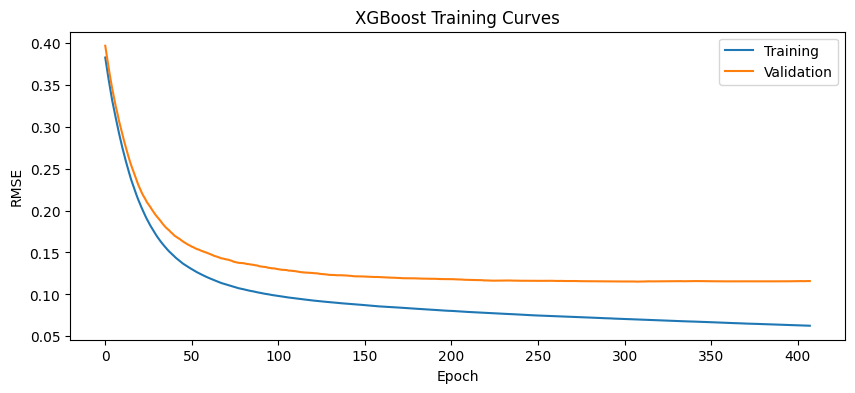

Best iteration: 307
Best validation RMSE: 0.1152


In [23]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(train, y, test_size=0.2, random_state=42)

eval_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=100
)

eval_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=0
)

results = eval_model.evals_result()
epochs = len(results['validation_0']['rmse'])

plt.figure(figsize=(10, 4))
plt.plot(results['validation_0']['rmse'], label='Training')
plt.plot(results['validation_1']['rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('XGBoost Training Curves')
plt.legend()
plt.show()

print(f"Best iteration: {eval_model.best_iteration}")
print(f"Best validation RMSE: {eval_model.best_score:.4f}")

The validation curve nicely flattens; however, the training curve does continue to trend downwards which can lead to overfitting. While something to worry about, we will be including 2 other models so this will mitigate this effect. 

Now let's train the LightGBM regressor with the same cross validation check as the XGBoost. 

In [24]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgb_scores = cross_val_score(
    lgb_model, train, y,
    scoring='neg_root_mean_squared_error',
    cv=5
)

print(f"LightGBM CV RMSE: {-lgb_scores.mean():.4f} (std={lgb_scores.std():.4f})")

LightGBM CV RMSE: 0.1196 (std=0.0066)


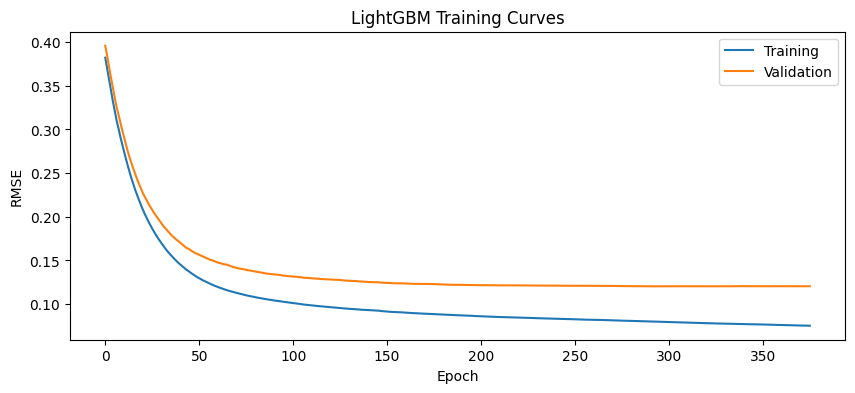

Best iteration: 326
Best validation RMSE: 0.1204


In [25]:
X_tr, X_val, y_tr, y_val = train_test_split(train, y, test_size=0.2, random_state=42)

# LightGBM validation curve
lgb_eval = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgb_eval.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

lgb_results = lgb_eval.evals_result_

plt.figure(figsize=(10, 4))
plt.plot(np.sqrt(lgb_results['training']['l2']), label='Training')
plt.plot(np.sqrt(lgb_results['valid_1']['l2']), label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('LightGBM Training Curves')
plt.legend()
plt.show()

print(f"Best iteration: {lgb_eval.best_iteration_}")
print(f"Best validation RMSE: {np.sqrt(lgb_eval.best_score_['valid_1']['l2']):.4f}")

A similar curve to the XGBoost. Ideally these two models complement each other to avoid overfitting effects. 

Finally on to the Ridge regressor. 

In [26]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Ridge needs scaled features
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

ridge_model = Ridge(alpha=200)

ridge_scores = cross_val_score(
    ridge_model, train_scaled, y,
    scoring='neg_root_mean_squared_error',
    cv=5
)

print(f"Ridge CV RMSE: {-ridge_scores.mean():.4f} (std={ridge_scores.std():.4f})")

Ridge CV RMSE: 0.1159 (std=0.0050)


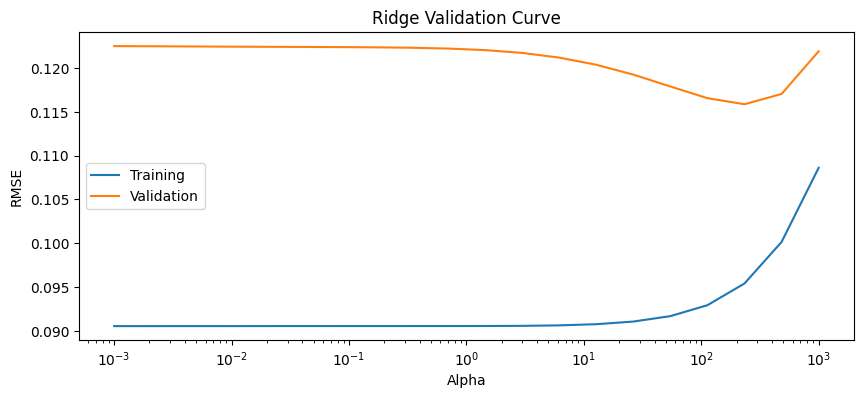

In [27]:
from sklearn.model_selection import validation_curve

alphas = np.logspace(-3, 3, 20)
train_scores, val_scores = validation_curve(
    Ridge(), train_scaled, y,
    param_name='alpha',
    param_range=alphas,
    scoring='neg_root_mean_squared_error',
    cv=5
)

plt.figure(figsize=(10, 4))
plt.semilogx(alphas, -train_scores.mean(axis=1), label='Training')
plt.semilogx(alphas, -val_scores.mean(axis=1), label='Validation')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Ridge Validation Curve')
plt.legend()
plt.show()

Here we search for the optimal alpha value balancing training and validation RMSE. The optimal alpha is clearly about 100. 

Now we will fit the models to the training data. Recall that we performed a log transformation in order to normalize the data; this means we now have to exponentiate our predictions. Finally we create an ensemble prediction and create a prediction file to be submitted. 

In [28]:
# Retrain all models on full data
model.fit(train, y)
lgb_model.fit(train, y)
ridge_model.fit(train_scaled, y)

# Predictions
xgb_preds = np.expm1(model.predict(test))
lgb_preds = np.expm1(lgb_model.predict(test))
ridge_preds = np.expm1(ridge_model.predict(test_scaled))

# Equal weight ensemble
ensemble_preds = (0.5*xgb_preds + 0.1*lgb_preds + 0.4*ridge_preds)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': ensemble_preds
})

submission.to_csv('submission.csv', index=False)

Now we explore the importance of the features to see how these models complement each other and to inform us about future improvements. 

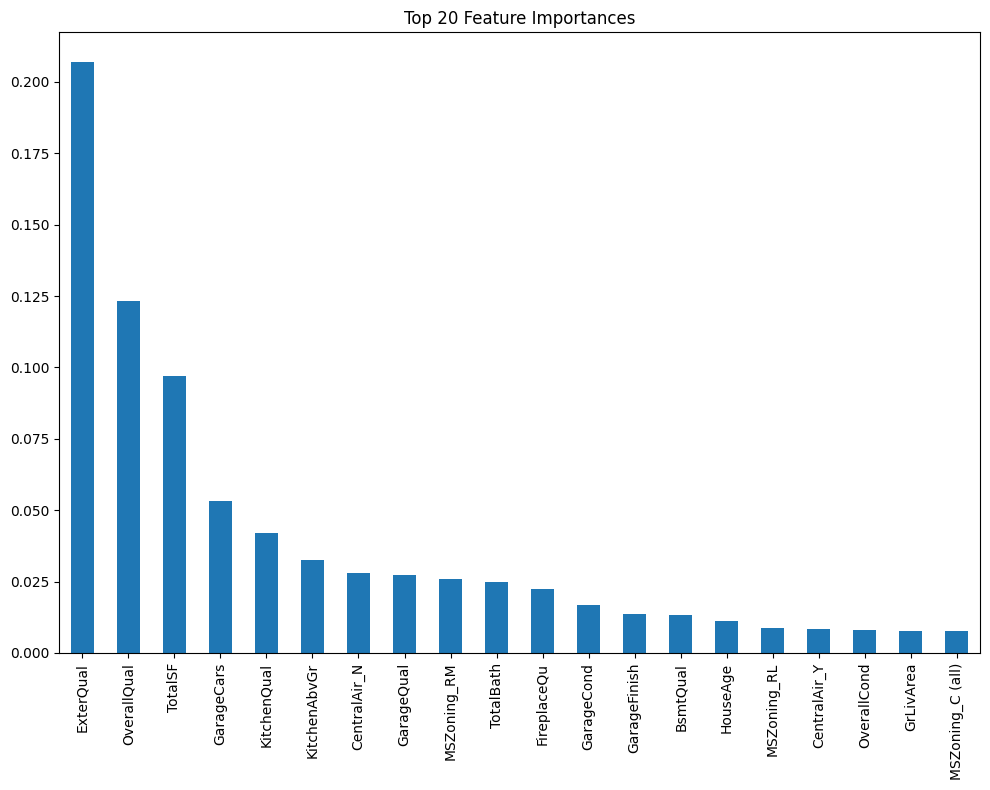

ExterQual           0.207023
OverallQual         0.123203
TotalSF             0.097070
GarageCars          0.053322
KitchenQual         0.042003
KitchenAbvGr        0.032462
CentralAir_N        0.028105
GarageQual          0.027174
MSZoning_RM         0.025978
TotalBath           0.024798
FireplaceQu         0.022216
GarageCond          0.016610
GarageFinish        0.013739
BsmtQual            0.013298
HouseAge            0.011001
MSZoning_RL         0.008879
CentralAir_Y        0.008395
OverallCond         0.008169
GrLivArea           0.007839
MSZoning_C (all)    0.007691
dtype: float32


In [29]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_importance[:20].plot(kind='bar')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print(feature_importance[:20])

Clearly the ordinal categories are very important to the XGBoost model. Also note that the engineered features TotalSF and TotalBath played important roles. 

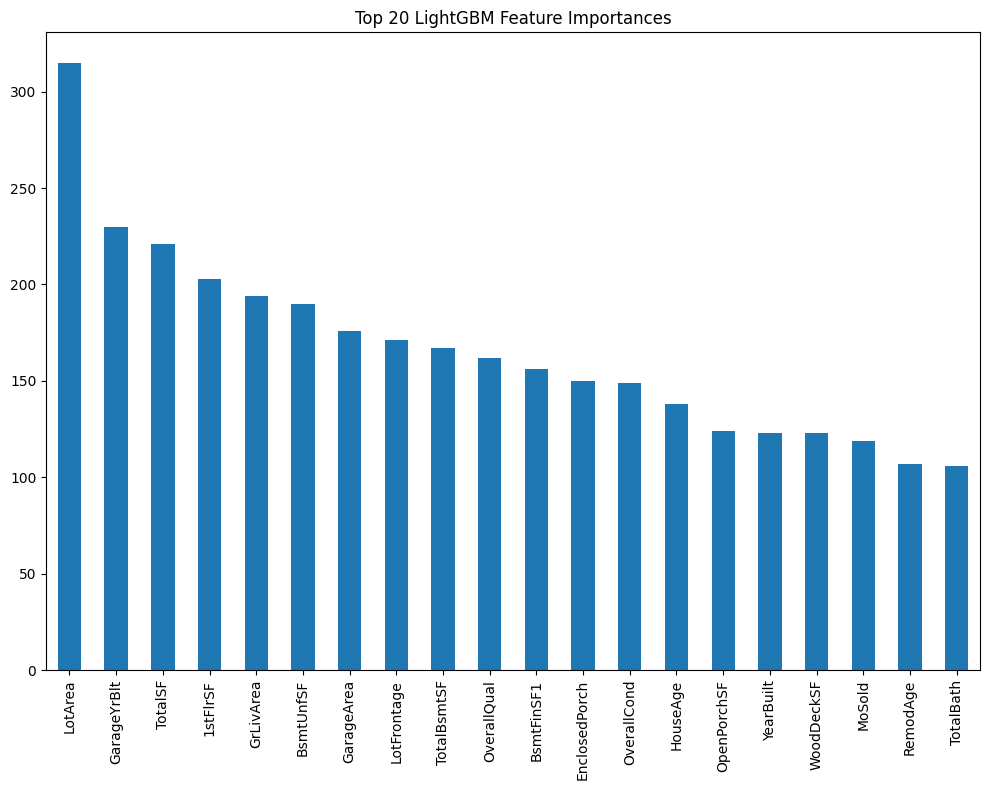

LotArea          315
GarageYrBlt      230
TotalSF          221
1stFlrSF         203
GrLivArea        194
BsmtUnfSF        190
GarageArea       176
LotFrontage      171
TotalBsmtSF      167
OverallQual      162
BsmtFinSF1       156
EnclosedPorch    150
OverallCond      149
HouseAge         138
OpenPorchSF      124
YearBuilt        123
WoodDeckSF       123
MoSold           119
RemodAge         107
TotalBath        106
dtype: int32


In [30]:
lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
lgb_importance[:20].plot(kind='bar')
plt.title('Top 20 LightGBM Feature Importances')
plt.tight_layout()
plt.show()

print(lgb_importance[:20])

Interestingly, while the same two engineered features play a role, the most important features for the LightGBM are the LotAreea and the GarageYrBlt; both of which are absent from the top 20 XGBoost features. A nice complement!

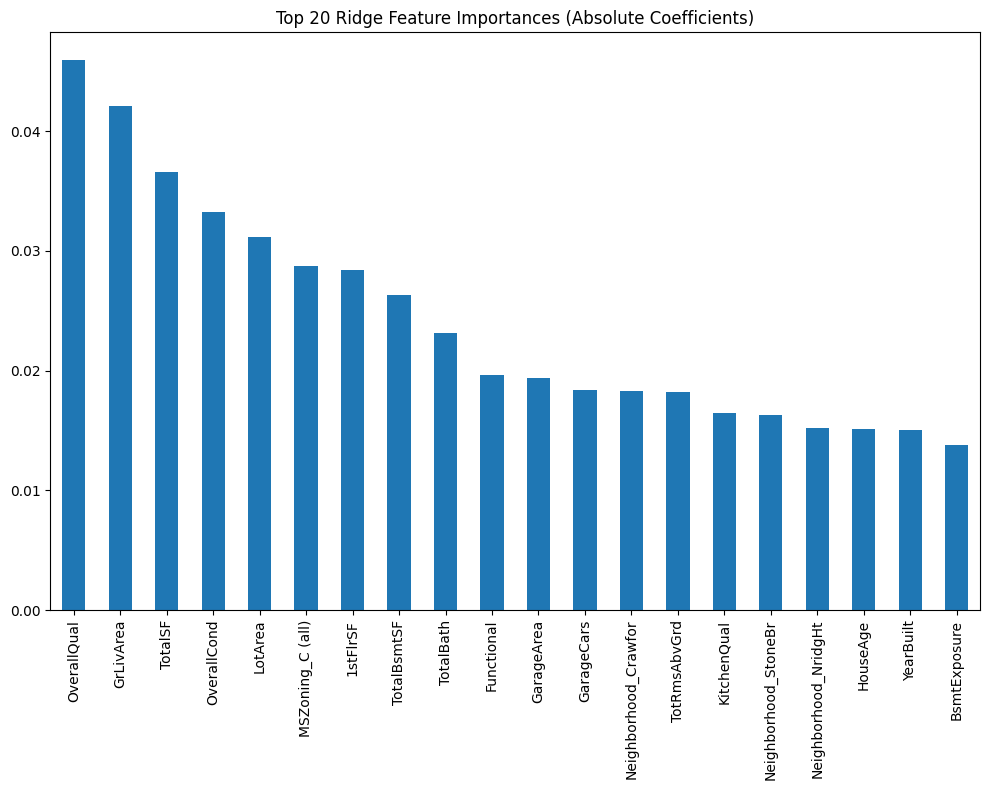

In [31]:
ridge_importance = pd.Series(
    np.abs(ridge_model.coef_),
    index=train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
ridge_importance[:20].plot(kind='bar')
plt.title('Top 20 Ridge Feature Importances (Absolute Coefficients)')
plt.tight_layout()
plt.show()

The ridge regressor feature impoprtance has a different shape than the other two models: this model seems to have a more evenly distributed feature importance. As a result some interesting features show up in the top 20, such as importance of neighborhood. 

In the end, this notebook trains an ensemble model to predict housing prices based on a variety of features that are numerical and categorical. The ensemble consists of XGBoost, LightGBM, and Ridge Regressor; these three models complement each other in a way that improves accuracy and reduces overfitting. 

